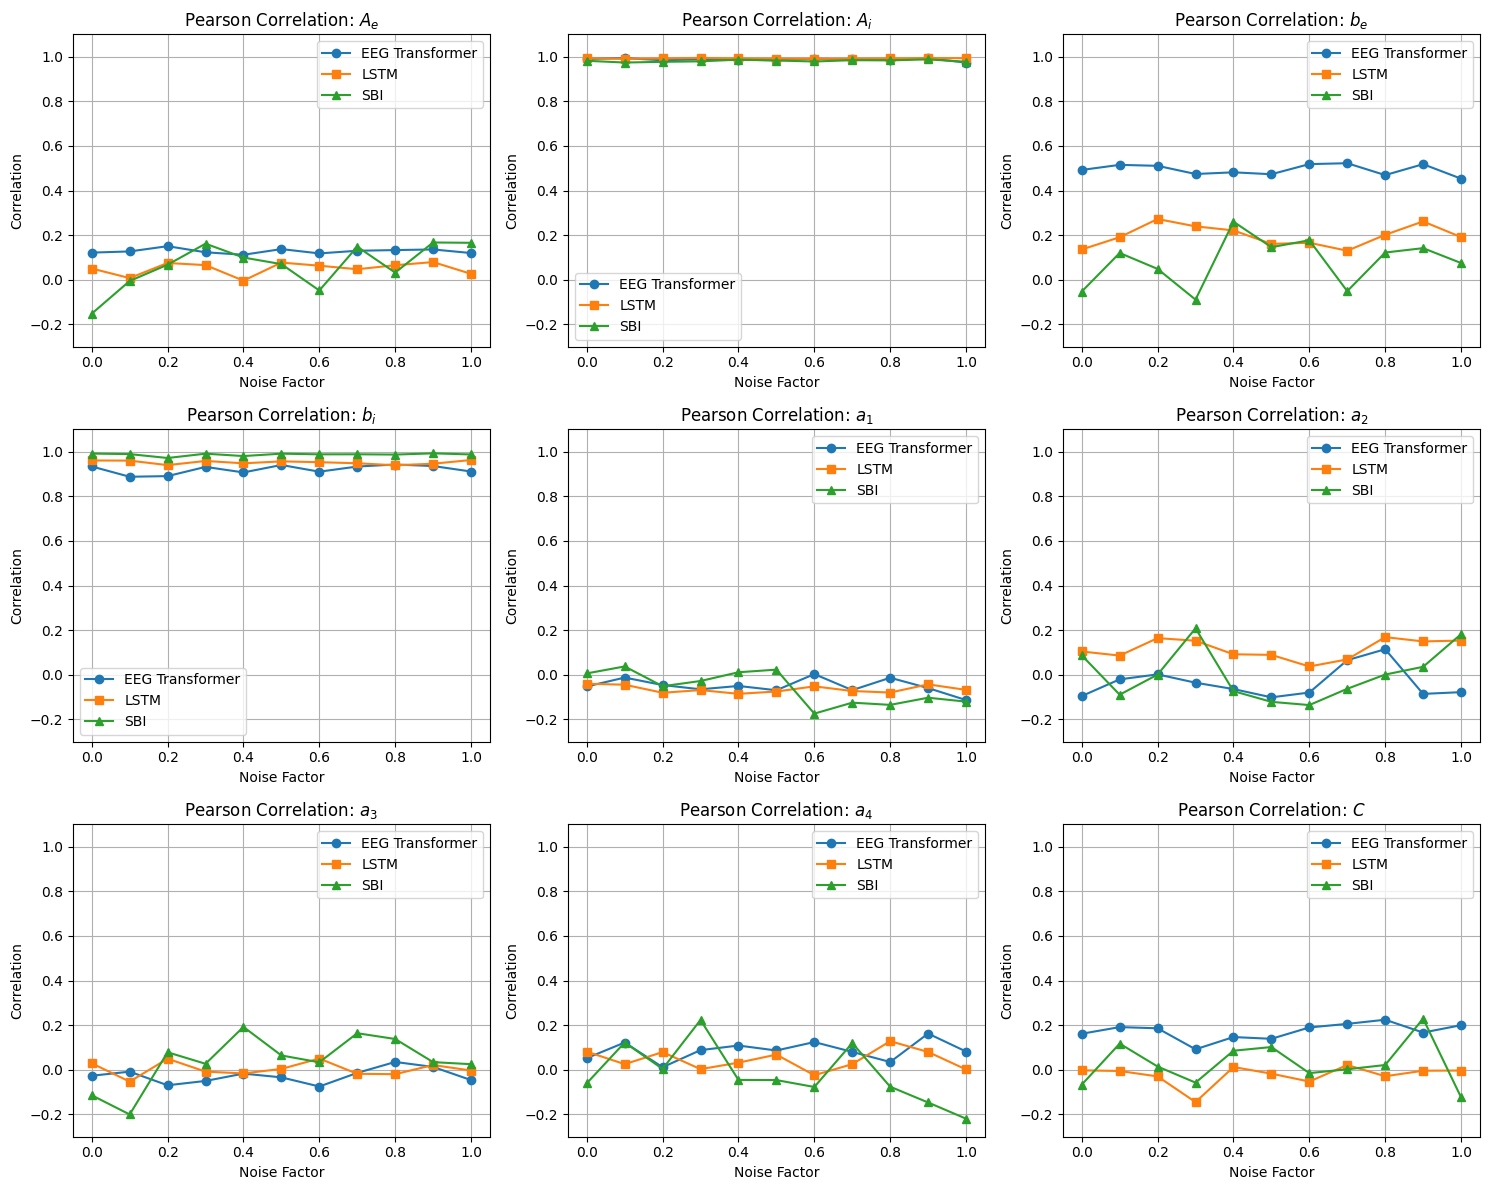

In [2]:
import re
import json
import numpy as np
import matplotlib.pyplot as plt

def parse_txt_file_all(filename):
    """
    Parses a text file with blocks in one of two formats:
    
    Format 1 (single line, e.g. EEG Transformer):
      Noise Factor: <noise>, MSE: <mse>, Correlations: { ... }
    
    Format 2 (multiline, e.g. LSTM):
      [Optional header]
      Noise Factor: <noise>, MSE: <mse>
      Correlations:
        <key>: Corr=<corr_value>, R²=<r2_value>
        <key2>: Corr=<corr_value>, R²=<r2_value>
        ...
    
    Returns:
      - noise_factors: list of noise values
      - correlations: dict where keys are parameter names and values are lists of the corresponding Pearson correlations.
    """
    noise_factors = []
    correlations = {}

    with open(filename, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue

        if "Noise Factor:" in line:
            # Extract the noise factor
            noise_match = re.search(r'Noise Factor:\s*([\d\.]+)', line)
            if noise_match:
                noise = float(noise_match.group(1))
                noise_factors.append(noise)
            else:
                i += 1
                continue

            # First try to see if correlations are on the same line
            corr_match = re.search(r'Correlations:\s*(\{.*\})', line)
            if corr_match:
                corr_str = corr_match.group(1)
                try:
                    corr_dict = eval(corr_str)
                except Exception as e:
                    print(f"Error parsing correlations: {e}")
                    i += 1
                    continue
                for key, value in corr_dict.items():
                    if key not in correlations:
                        correlations[key] = []
                    correlations[key].append(value)
                i += 1
                continue

            # If not, assume the correlations follow in subsequent lines.
            # Skip to the next non-empty line that should be "Correlations:"
            i += 1
            while i < len(lines) and lines[i].strip() == "":
                i += 1
            if i < len(lines) and "Correlations:" in lines[i]:
                i += 1  # Move past the "Correlations:" line
            else:
                continue

            # Process subsequent lines that contain correlation entries.
            while i < len(lines):
                corr_line = lines[i].strip()
                if not corr_line:
                    break
                # If a new block begins, break out of the inner loop.
                if "Noise Factor:" in corr_line:
                    break
                # Expected format: <key>: Corr=<value>, R²=<value>
                corr_line_match = re.match(r'([\w]+):\s*Corr=([-\d\.]+)', corr_line)
                if corr_line_match:
                    key = corr_line_match.group(1)
                    value = float(corr_line_match.group(2))
                    if key not in correlations:
                        correlations[key] = []
                    correlations[key].append(value)
                i += 1
        else:
            i += 1
    return noise_factors, correlations

# Parse the EEG Transformer and LSTM text files
noise_eeg, corr_eeg = parse_txt_file_all('evaluation_results_eegtransformer.txt')
noise_lstm, corr_lstm = parse_txt_file_all('evaluation_results_lstm.txt')

# Load and parse the SBI JSON file (keys are noise factors)
with open('evalution_results_sbi.json', 'r') as f:
    sbi_data = json.load(f)

noise_sbi = []
corr_sbi = {}
for noise_str, metrics in sbi_data.items():
    try:
        noise = float(noise_str)
    except ValueError:
        continue
    noise_sbi.append(noise)
    for key, value in metrics.items():
        if key not in corr_sbi:
            corr_sbi[key] = []
        corr_sbi[key].append(value)

# Function to sort noise factors and corresponding correlation values
def sort_data(noise, correlations):
    noise = np.array(noise)
    sorted_idx = np.argsort(noise)
    noise_sorted = noise[sorted_idx]
    correlations_sorted = {}
    for key, values in correlations.items():
        correlations_sorted[key] = np.array(values)[sorted_idx]
    return noise_sorted, correlations_sorted

noise_eeg, corr_eeg = sort_data(noise_eeg, corr_eeg)
noise_lstm, corr_lstm = sort_data(noise_lstm, corr_lstm)
noise_sbi, corr_sbi = sort_data(noise_sbi, corr_sbi)

# Define the list of correlation keys to plot (common to all models)
common_keys = ['A_e', 'A_i', 'b_e', 'b_i', 'a_1', 'a_2', 'a_3', 'a_4', 'C']

# Create a grid of subplots (3 rows x 3 columns for 9 parameters)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, key in enumerate(common_keys):
    ax = axes[i]
    # Plot data for each model if the key exists
    if key in corr_eeg:
        ax.plot(noise_eeg, corr_eeg[key], marker='o', label='EEG Transformer')
    if key in corr_lstm:
        ax.plot(noise_lstm, corr_lstm[key], marker='s', label='LSTM')
    if key in corr_sbi:
        ax.plot(noise_sbi, corr_sbi[key], marker='^', label='SBI')
    
    # Use LaTeX formatting for parameter names (e.g. A_e renders e as subscript)
    ax.set_title('Pearson Correlation: $' + key + '$')
    ax.set_xlabel('Noise Factor')
    ax.set_ylabel('Correlation')
    ax.set_ylim(-0.3, 1.1)  # (min, max)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


In [2]:
noise_lstm, corr_lstm = parse_txt_file_all('evaluation_results_lstm.txt')

/var/folders/q2/0fx0g8ps73191hn2jpcbj1mm0000gn/T/ipykernel_1134/3391558080.py:290: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


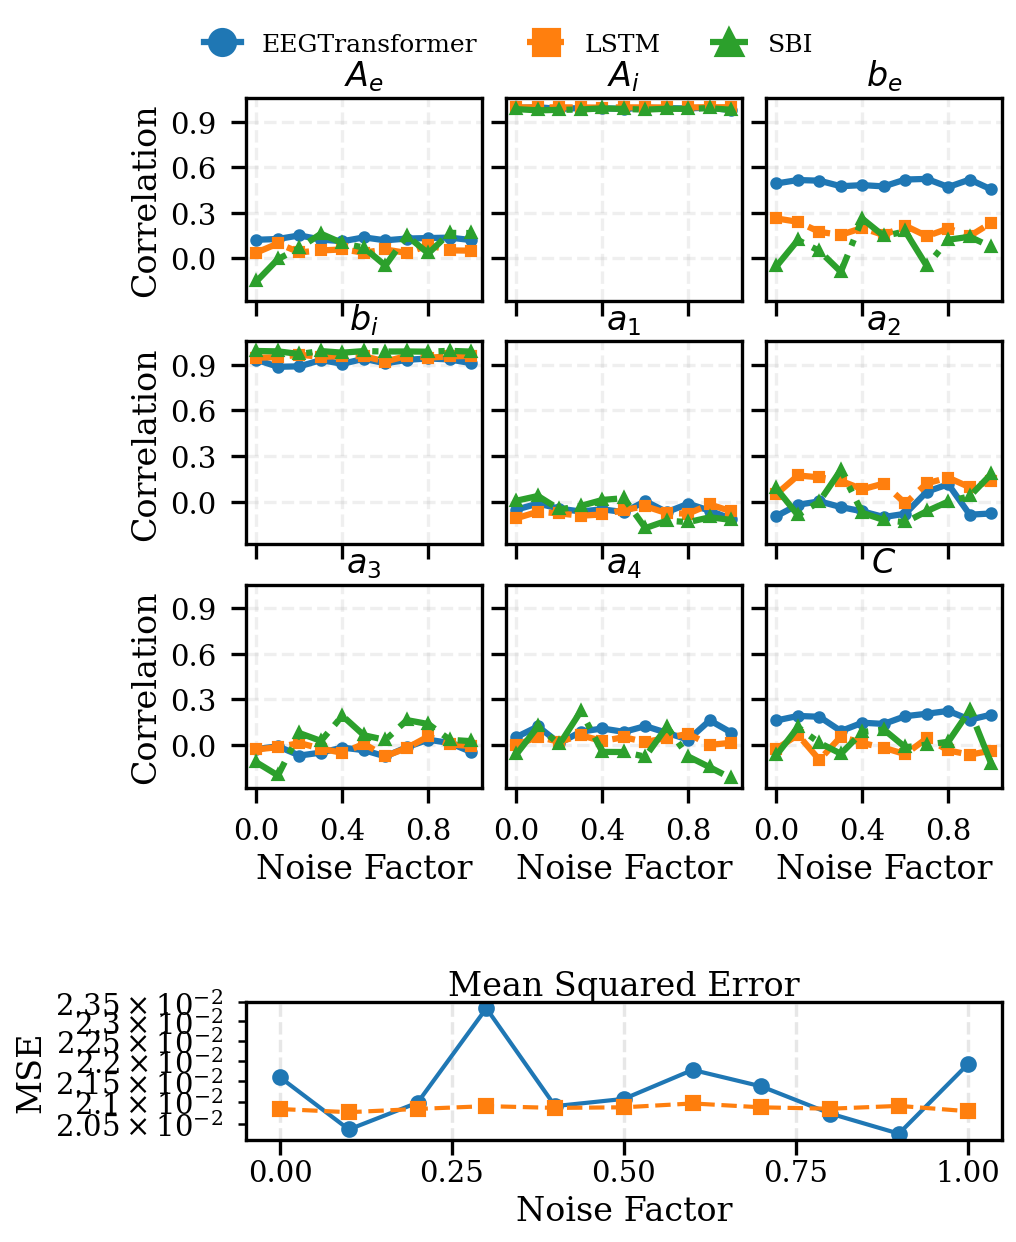

In [6]:
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

def parse_txt_file_all(filename):
    """
    Parses a text file that may have two possible formats:
    
    Format 1 (single-line, e.g. EEG Transformer):
      Noise Factor: <noise>, MSE: <mse>, Correlations: { ... }
      
    Format 2 (multi-line, e.g. LSTM):
      [Optional header]
      Noise Factor: <noise>, MSE: <mse>
      Correlations:
        <key>: Corr=<corr_value>, R²=<r2_value>
        <key2>: Corr=<corr_value>, R²=<r2_value>
        ...
    
    Returns:
      - noise_factors: list of noise values (floats)
      - mse_values: list of MSE values (floats or None if missing)
      - correlations: dict where keys are parameter names and values are lists of the corresponding Pearson correlations.
    """
    noise_factors = []
    mse_values = []
    correlations = {}

    with open(filename, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue

        if "Noise Factor:" in line:
            # Extract noise factor and MSE from the line
            noise_match = re.search(r'Noise Factor:\s*([\d\.]+)', line)
            mse_match = re.search(r'MSE:\s*([\d\.eE\-\+]+)', line)
            if noise_match:
                noise = float(noise_match.group(1))
            else:
                i += 1
                continue
            mse = float(mse_match.group(1)) if mse_match else None

            noise_factors.append(noise)
            mse_values.append(mse)

            # Check if correlations dictionary is provided on the same line
            corr_match = re.search(r'Correlations:\s*(\{.*\})', line)
            if corr_match:
                corr_str = corr_match.group(1)
                try:
                    corr_dict = eval(corr_str)  # Ensure the file is trusted!
                except Exception as e:
                    print(f"Error parsing correlations in {filename}: {e}")
                    i += 1
                    continue
                for key, value in corr_dict.items():
                    if key not in correlations:
                        correlations[key] = []
                    correlations[key].append(value)
                i += 1
                continue

            # Otherwise, assume correlations follow on subsequent lines.
            # Skip blank lines until a line containing "Correlations:" is found.
            i += 1
            while i < len(lines) and lines[i].strip() == "":
                i += 1
            if i < len(lines) and "Correlations:" in lines[i]:
                i += 1  # Skip the "Correlations:" line
            else:
                continue

            # Process subsequent lines for correlation entries.
            while i < len(lines):
                corr_line = lines[i].strip()
                if not corr_line:
                    break
                # If a new block begins, stop processing the current block.
                if "Noise Factor:" in corr_line:
                    break
                # Expected format: <key>: Corr=<value>, R²=<value>
                corr_line_match = re.match(r'([\w]+):\s*Corr=([-\d\.]+)', corr_line)
                if corr_line_match:
                    key = corr_line_match.group(1)
                    try:
                        value = float(corr_line_match.group(2))
                    except ValueError:
                        value = None
                    if key not in correlations:
                        correlations[key] = []
                    correlations[key].append(value)
                i += 1
        else:
            i += 1

    return noise_factors, mse_values, correlations

# Parse the EEG Transformer and LSTM text files
noise_eeg, mse_eeg, corr_eeg = parse_txt_file_all('evaluation_results_eegtransformer.txt')
noise_lstm, mse_lstm, corr_lstm = parse_txt_file_all('evaluation_results_lstm.txt')

# Load and parse the SBI JSON file (keys are noise factors)
with open('evalution_results_sbi.json', 'r') as f:
    sbi_data = json.load(f)

noise_sbi = []
mse_sbi = []
corr_sbi = {}
for noise_str, metrics in sbi_data.items():
    try:
        noise = float(noise_str)
    except ValueError:
        continue
    noise_sbi.append(noise)
    
    # Check if MSE is available in SBI data
    if 'MSE' in metrics:
        mse_sbi.append(metrics['MSE'])
    else:
        mse_sbi.append(None)
        
    for key, value in metrics.items():
        if key == 'MSE':
            continue
        if key not in corr_sbi:
            corr_sbi[key] = []
        corr_sbi[key].append(value)

def sort_data(noise, mse, correlations):
    """Sort noise, mse, and correlations by ascending noise factor."""
    noise = np.array(noise)
    sorted_idx = np.argsort(noise)
    noise_sorted = noise[sorted_idx]
    
    # Sort MSE values if they exist
    if mse and len(mse) > 0:
        mse_sorted = np.array(mse, dtype=float)[sorted_idx]
    else:
        mse_sorted = np.array([])
    
    correlations_sorted = {}
    for key, values in correlations.items():
        correlations_sorted[key] = np.array(values)[sorted_idx]
    
    return noise_sorted, mse_sorted, correlations_sorted

noise_eeg, mse_eeg, corr_eeg = sort_data(noise_eeg, mse_eeg, corr_eeg)
noise_lstm, mse_lstm, corr_lstm = sort_data(noise_lstm, mse_lstm, corr_lstm)
noise_sbi, mse_sbi, corr_sbi = sort_data(noise_sbi, mse_sbi, corr_sbi)

# Define the list of correlation keys to plot (common to all models)
common_keys = ['A_e', 'A_i', 'b_e', 'b_i', 'a_1', 'a_2', 'a_3', 'a_4', 'C']

# Gather min and max correlation values across all models and keys
all_corr_values = []
for key in common_keys:
    if key in corr_eeg:
        all_corr_values.extend(corr_eeg[key])
    if key in corr_lstm:
        all_corr_values.extend(corr_lstm[key])
    if key in corr_sbi:
        all_corr_values.extend(corr_sbi[key])

if all_corr_values:
    global_min_corr = min(all_corr_values)
    global_max_corr = max(all_corr_values)
    # Add a small margin so points don't sit on the boundary
    margin = 0.05 * (global_max_corr - global_min_corr)
    if margin == 0:  # In case all values are the same
        margin = 0.1
    global_min_corr -= margin
    global_max_corr += margin
else:
    global_min_corr, global_max_corr = -0.3, 1.05

# Plot style for single column
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.labelpad': 2,
    'axes.titlepad': 3,
})

fig = plt.figure(figsize=(3.5, 4.0))

# Reduce the spacing between the two subfigures
subfigs = fig.subfigures(2, 1, height_ratios=[5, 1])

markers = {'EEGTransformer': 'o', 'LSTM': 's', 'SBI': '^'}
colors = {'EEGTransformer': '#1f77b4', 'LSTM': '#ff7f0e', 'SBI': '#2ca02c'}
linestyles = {'EEGTransformer': '-', 'LSTM': '--', 'SBI': '-.'}

# Top subfigure for parameter correlations (3x3 grid)
axs_params = subfigs[0].subplots(3, 3, sharex=True, sharey=True,
                                 gridspec_kw={'wspace': 0.1, 'hspace': 0.2})
axs_params = axs_params.flatten()

for i, key in enumerate(common_keys):
    ax = axs_params[i]
    
    if key in corr_eeg:
        ax.plot(noise_eeg, corr_eeg[key],
                marker=markers['EEGTransformer'],
                color=colors['EEGTransformer'],
                linestyle=linestyles['EEGTransformer'],
                markersize=2)
    if key in corr_lstm:
        ax.plot(noise_lstm, corr_lstm[key],
                marker=markers['LSTM'],
                color=colors['LSTM'],
                linestyle=linestyles['LSTM'],
                markersize=2)
    if key in corr_sbi:
        ax.plot(noise_sbi, corr_sbi[key],
                marker=markers['SBI'],
                color=colors['SBI'],
                linestyle=linestyles['SBI'],
                markersize=2)
    
    # Format parameter name with subscript if needed
    if '_' in key:
        parts = key.split('_')
        main_param = parts[0]
        subscript = parts[1]
        param_formatted = main_param + '_{' + subscript + '}'
    else:
        param_formatted = key
    ax.set_title(f"${param_formatted}$", pad=3)
    
    ax.grid(True, linestyle='--', alpha=0.2)
    ax.set_ylim(global_min_corr, global_max_corr)
    
    if i % 3 == 0:
        ax.set_ylabel("Correlation", labelpad=2)
    if i >= 6:
        ax.set_xlabel("Noise Factor", labelpad=2)
    
    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.yaxis.set_major_locator(MaxNLocator(5))
    
# Bottom subfigure for MSE plot
has_mse_data = (isinstance(mse_eeg, np.ndarray) and mse_eeg.size > 0 and np.any(~np.isnan(mse_eeg))) or \
               (isinstance(mse_lstm, np.ndarray) and mse_lstm.size > 0 and np.any(~np.isnan(mse_lstm)))

if has_mse_data:
    ax_mse = subfigs[1].subplots(1, 1)
    
    if isinstance(mse_eeg, np.ndarray) and mse_eeg.size > 0 and np.any(~np.isnan(mse_eeg)):
        ax_mse.plot(noise_eeg, mse_eeg, marker=markers['EEGTransformer'],
                    color=colors['EEGTransformer'],
                    linestyle=linestyles['EEGTransformer'],
                    markersize=3, linewidth=1, label='EEGTransformer')
    if isinstance(mse_lstm, np.ndarray) and mse_lstm.size > 0 and np.any(~np.isnan(mse_lstm)):
        ax_mse.plot(noise_lstm, mse_lstm, marker=markers['LSTM'],
                    color=colors['LSTM'],
                    linestyle=linestyles['LSTM'],
                    markersize=3, linewidth=1, label='LSTM')
    
    ax_mse.set_title("Mean Squared Error", pad=1, fontsize=8)
    ax_mse.set_xlabel("Noise Factor", labelpad=2)
    ax_mse.set_ylabel("MSE", labelpad=2)
    ax_mse.grid(True, linestyle='--', alpha=0.3)
    ax_mse.set_yscale('log')
    ax_mse.xaxis.set_major_locator(MaxNLocator(5))
    ax_mse.tick_params(pad=1)
    subfigs[1].set_visible(True)
else:
    subfigs[1].set_visible(False)

plt.tight_layout()

filename_base = 'parameter_correlations'
if has_mse_data:
    filename_base += '_with_mse'

# Create a dedicated legend axes.
legend_ax = fig.add_axes([0.25, 0.92, 0.5, 0.05])
legend_ax.axis('off')  # Hide frame and ticks

# Custom legend handles
handles = [
    mpl.lines.Line2D([], [], marker=markers['EEGTransformer'],
                     linestyle=linestyles['EEGTransformer'],
                     color=colors['EEGTransformer'],
                     label='EEGTransformer'),
    mpl.lines.Line2D([], [], marker=markers['LSTM'],
                     linestyle=linestyles['LSTM'],
                     color=colors['LSTM'],
                     label='LSTM'),
    mpl.lines.Line2D([], [], marker=markers['SBI'],
                     linestyle=linestyles['SBI'],
                     color=colors['SBI'],
                     label='SBI')
]

legend = legend_ax.legend(handles=handles,
                          loc='center',
                          ncol=3,
                          fontsize=6,
                          frameon=False,
                          handlelength=1.5)

plt.subplots_adjust(top=0.88)

plt.savefig(f'{filename_base}.pdf', bbox_inches='tight')
plt.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/q2/0fx0g8ps73191hn2jpcbj1mm0000gn/T/ipykernel_18887/2084874327.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


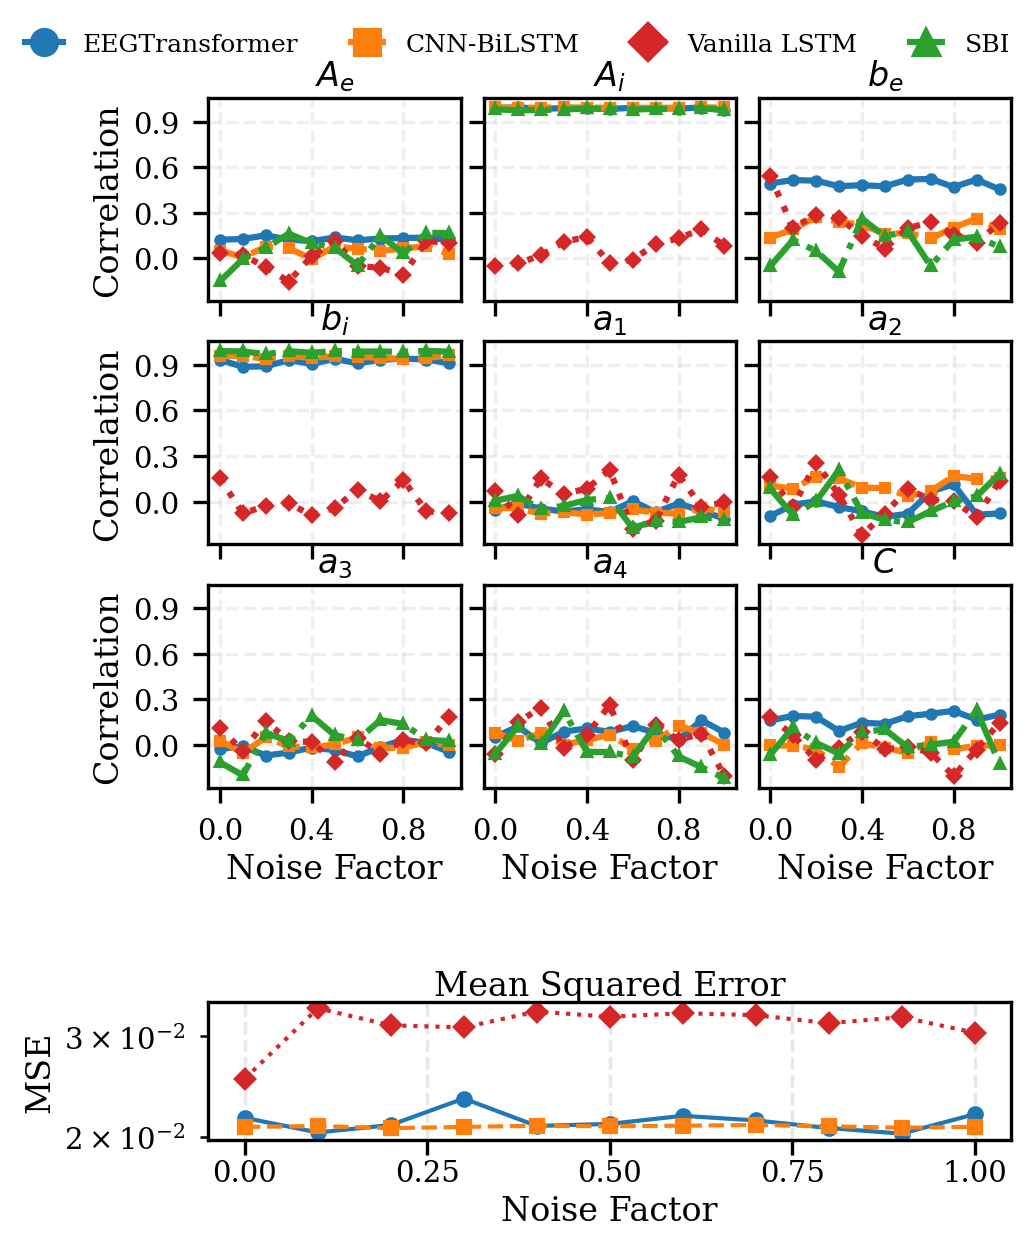

In [3]:
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

def parse_txt_file_all(filename):
    """
    Parses a text file that may have two possible formats:
    
    Format 1 (single-line, e.g. EEG Transformer):
      Noise Factor: <noise>, MSE: <mse>, Correlations: { ... }
      
    Format 2 (multi-line, e.g. LSTM):
      [Optional header]
      Noise Factor: <noise>, MSE: <mse>
      Correlations:
        <key>: Corr=<corr_value>, R²=<r2_value>
        <key2>: Corr=<corr_value>, R²=<r2_value>
        ...
    
    Returns:
      - noise_factors: list of noise values (floats)
      - mse_values: list of MSE values (floats or None if missing)
      - correlations: dict where keys are parameter names and values are lists of the corresponding Pearson correlations.
    """
    noise_factors = []
    mse_values = []
    correlations = {}

    with open(filename, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue

        if "Noise Factor:" in line:
            # Extract noise factor and MSE from the line
            noise_match = re.search(r'Noise Factor:\s*([\d\.]+)', line)
            mse_match = re.search(r'MSE:\s*([\d\.eE\-\+]+)', line)
            if noise_match:
                noise = float(noise_match.group(1))
            else:
                i += 1
                continue
            mse = float(mse_match.group(1)) if mse_match else None

            noise_factors.append(noise)
            mse_values.append(mse)

            # Check if correlations dictionary is provided on the same line
            corr_match = re.search(r'Correlations:\s*(\{.*\})', line)
            if corr_match:
                corr_str = corr_match.group(1)
                try:
                    corr_dict = eval(corr_str)  # Ensure the file is trusted!
                except Exception as e:
                    print(f"Error parsing correlations in {filename}: {e}")
                    i += 1
                    continue
                for key, value in corr_dict.items():
                    if key not in correlations:
                        correlations[key] = []
                    correlations[key].append(value)
                i += 1
                continue

            # Otherwise, assume correlations follow on subsequent lines.
            # Skip blank lines until a line containing "Correlations:" is found.
            i += 1
            while i < len(lines) and lines[i].strip() == "":
                i += 1
            if i < len(lines) and "Correlations:" in lines[i]:
                i += 1  # Skip the "Correlations:" line
            else:
                continue

            # Process subsequent lines for correlation entries.
            while i < len(lines):
                corr_line = lines[i].strip()
                if not corr_line:
                    break
                # If a new block begins, stop processing the current block.
                if "Noise Factor:" in corr_line:
                    break
                # Expected format: <key>: Corr=<value>, R²=<value>
                corr_line_match = re.match(r'([\w]+):\s*Corr=([-\d\.]+)', corr_line)
                if corr_line_match:
                    key = corr_line_match.group(1)
                    try:
                        value = float(corr_line_match.group(2))
                    except ValueError:
                        value = None
                    if key not in correlations:
                        correlations[key] = []
                    correlations[key].append(value)
                i += 1
        else:
            i += 1

    return noise_factors, mse_values, correlations

# Parse the EEG Transformer and LSTM text files
noise_eeg, mse_eeg, corr_eeg = parse_txt_file_all('evaluation_results_eegtransformer.txt')
noise_lstm, mse_lstm, corr_lstm = parse_txt_file_all('evaluation_results_lstm.txt')
# Parse the base LSTM text file
noise_lstm_old, mse_lstm_old, corr_lstm_old = parse_txt_file_all('evaluation_results_lstm_old.txt')

# Load and parse the SBI JSON file (keys are noise factors)
with open('evalution_results_sbi.json', 'r') as f:
    sbi_data = json.load(f)

noise_sbi = []
mse_sbi = []
corr_sbi = {}
for noise_str, metrics in sbi_data.items():
    try:
        noise = float(noise_str)
    except ValueError:
        continue
    noise_sbi.append(noise)
    
    # Check if MSE is available in SBI data
    if 'MSE' in metrics:
        mse_sbi.append(metrics['MSE'])
    else:
        mse_sbi.append(None)
        
    for key, value in metrics.items():
        if key == 'MSE':
            continue
        if key not in corr_sbi:
            corr_sbi[key] = []
        corr_sbi[key].append(value)

def sort_data(noise, mse, correlations):
    """Sort noise, mse, and correlations by ascending noise factor."""
    noise = np.array(noise)
    sorted_idx = np.argsort(noise)
    noise_sorted = noise[sorted_idx]
    
    # Sort MSE values if they exist
    if mse and len(mse) > 0:
        mse_sorted = np.array(mse, dtype=float)[sorted_idx]
    else:
        mse_sorted = np.array([])
    
    correlations_sorted = {}
    for key, values in correlations.items():
        correlations_sorted[key] = np.array(values)[sorted_idx]
    
    return noise_sorted, mse_sorted, correlations_sorted

noise_eeg, mse_eeg, corr_eeg = sort_data(noise_eeg, mse_eeg, corr_eeg)
noise_lstm, mse_lstm, corr_lstm = sort_data(noise_lstm, mse_lstm, corr_lstm)
noise_lstm_old, mse_lstm_old, corr_lstm_old = sort_data(noise_lstm_old, mse_lstm_old, corr_lstm_old)
noise_sbi, mse_sbi, corr_sbi = sort_data(noise_sbi, mse_sbi, corr_sbi)

# Define the list of correlation keys to plot (common to all models)
common_keys = ['A_e', 'A_i', 'b_e', 'b_i', 'a_1', 'a_2', 'a_3', 'a_4', 'C']

# Gather min and max correlation values across all models and keys
all_corr_values = []
for key in common_keys:
    if key in corr_eeg:
        all_corr_values.extend(corr_eeg[key])
    if key in corr_lstm:
        all_corr_values.extend(corr_lstm[key])
    if key in corr_lstm_old:
        all_corr_values.extend(corr_lstm_old[key])
    if key in corr_sbi:
        all_corr_values.extend(corr_sbi[key])

if all_corr_values:
    global_min_corr = min(all_corr_values)
    global_max_corr = max(all_corr_values)
    # Add a small margin so points don't sit on the boundary
    margin = 0.05 * (global_max_corr - global_min_corr)
    if margin == 0:  # In case all values are the same
        margin = 0.1
    global_min_corr -= margin
    global_max_corr += margin
else:
    global_min_corr, global_max_corr = -0.3, 1.05

# Plot style for single column
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.labelpad': 2,
    'axes.titlepad': 3,
})

fig = plt.figure(figsize=(3.5, 4.0))

# Reduce the spacing between the two subfigures
subfigs = fig.subfigures(2, 1, height_ratios=[5, 1])

markers = {'EEGTransformer': 'o', 'LSTM': 's', 'LSTM_Old': 'D', 'SBI': '^'}
colors = {'EEGTransformer': '#1f77b4', 'LSTM': '#ff7f0e', 'LSTM_Old': '#d62728', 'SBI': '#2ca02c'}
linestyles = {'EEGTransformer': '-', 'LSTM': '--', 'LSTM_Old': ':', 'SBI': '-.'}

# Top subfigure for parameter correlations (3x3 grid)
axs_params = subfigs[0].subplots(3, 3, sharex=True, sharey=True,
                                 gridspec_kw={'wspace': 0.09, 'hspace': 0.2})
axs_params = axs_params.flatten()

for i, key in enumerate(common_keys):
    ax = axs_params[i]
    
    if key in corr_eeg:
        ax.plot(noise_eeg, corr_eeg[key],
                marker=markers['EEGTransformer'],
                color=colors['EEGTransformer'],
                linestyle=linestyles['EEGTransformer'],
                markersize=2)
    if key in corr_lstm:
        ax.plot(noise_lstm, corr_lstm[key],
                marker=markers['LSTM'],
                color=colors['LSTM'],
                linestyle=linestyles['LSTM'],
                markersize=2)
    if key in corr_lstm_old:
        ax.plot(noise_lstm_old, corr_lstm_old[key],
                marker=markers['LSTM_Old'],
                color=colors['LSTM_Old'],
                linestyle=linestyles['LSTM_Old'],
                markersize=2)
    if key in corr_sbi:
        ax.plot(noise_sbi, corr_sbi[key],
                marker=markers['SBI'],
                color=colors['SBI'],
                linestyle=linestyles['SBI'],
                markersize=2)
    
    # Format parameter name with subscript if needed
    if '_' in key:
        parts = key.split('_')
        main_param = parts[0]
        subscript = parts[1]
        param_formatted = main_param + '_{' + subscript + '}'
    else:
        param_formatted = key
    ax.set_title(f"${param_formatted}$", pad=3)
    
    ax.grid(True, linestyle='--', alpha=0.2)
    ax.set_ylim(global_min_corr, global_max_corr)
    
    if i % 3 == 0:
        ax.set_ylabel("Correlation", labelpad=2)
    if i >= 6:
        ax.set_xlabel("Noise Factor", labelpad=2)
    
    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.yaxis.set_major_locator(MaxNLocator(5))
    
# Bottom subfigure for MSE plot
has_mse_data = (isinstance(mse_eeg, np.ndarray) and mse_eeg.size > 0 and np.any(~np.isnan(mse_eeg))) or \
               (isinstance(mse_lstm, np.ndarray) and mse_lstm.size > 0 and np.any(~np.isnan(mse_lstm))) or \
               (isinstance(mse_lstm_old, np.ndarray) and mse_lstm_old.size > 0 and np.any(~np.isnan(mse_lstm_old)))

if has_mse_data:
    ax_mse = subfigs[1].subplots(1, 1)
    
    if isinstance(mse_eeg, np.ndarray) and mse_eeg.size > 0 and np.any(~np.isnan(mse_eeg)):
        ax_mse.plot(noise_eeg, mse_eeg, marker=markers['EEGTransformer'],
                    color=colors['EEGTransformer'],
                    linestyle=linestyles['EEGTransformer'],
                    markersize=3, linewidth=1, label='EEGTransformer')
    if isinstance(mse_lstm, np.ndarray) and mse_lstm.size > 0 and np.any(~np.isnan(mse_lstm)):
        ax_mse.plot(noise_lstm, mse_lstm, marker=markers['LSTM'],
                    color=colors['LSTM'],
                    linestyle=linestyles['LSTM'],
                    markersize=3, linewidth=1, label='Enhanced BiLSTM')
    if isinstance(mse_lstm_old, np.ndarray) and mse_lstm_old.size > 0 and np.any(~np.isnan(mse_lstm_old)):
        ax_mse.plot(noise_lstm_old, mse_lstm_old, marker=markers['LSTM_Old'],
                    color=colors['LSTM_Old'],
                    linestyle=linestyles['LSTM_Old'],
                    markersize=3, linewidth=1, label='Vanilla LSTM')
    
    ax_mse.set_title("Mean Squared Error", pad=1, fontsize=8)
    ax_mse.set_xlabel("Noise Factor", labelpad=2)
    ax_mse.set_ylabel("MSE", labelpad=2)
    ax_mse.grid(True, linestyle='--', alpha=0.3)
    ax_mse.set_yscale('log')
    ax_mse.xaxis.set_major_locator(MaxNLocator(5))
    ax_mse.tick_params(pad=1)
    subfigs[1].set_visible(True)
else:
    subfigs[1].set_visible(False)

plt.tight_layout()

filename_base = 'parameter_correlations'
if has_mse_data:
    filename_base += '_with_mse'

# Create a dedicated legend axes.
legend_ax = fig.add_axes([0.1, 0.92, 0.8, 0.05])
legend_ax.axis('off')  # Hide frame and ticks

# Custom legend handles
handles = [
    mpl.lines.Line2D([], [], marker=markers['EEGTransformer'],
                     linestyle=linestyles['EEGTransformer'],
                     color=colors['EEGTransformer'],
                     label='EEGTransformer'),
    mpl.lines.Line2D([], [], marker=markers['LSTM'],
                     linestyle=linestyles['LSTM'],
                     color=colors['LSTM'],
                     label='CNN-BiLSTM'),
    mpl.lines.Line2D([], [], marker=markers['LSTM_Old'],
                     linestyle=linestyles['LSTM_Old'],
                     color=colors['LSTM_Old'],
                     label='Vanilla LSTM'),
    mpl.lines.Line2D([], [], marker=markers['SBI'],
                     linestyle=linestyles['SBI'],
                     color=colors['SBI'],
                     label='SBI')
]

legend = legend_ax.legend(handles=handles,
                          loc='center',
                          ncol=4,
                          fontsize=6,
                          frameon=False,
                          handlelength=1.5)

plt.subplots_adjust(top=0.88)

plt.savefig(f'{filename_base}.pdf', bbox_inches='tight')
plt.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/q2/0fx0g8ps73191hn2jpcbj1mm0000gn/T/ipykernel_18887/3290115112.py:299: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


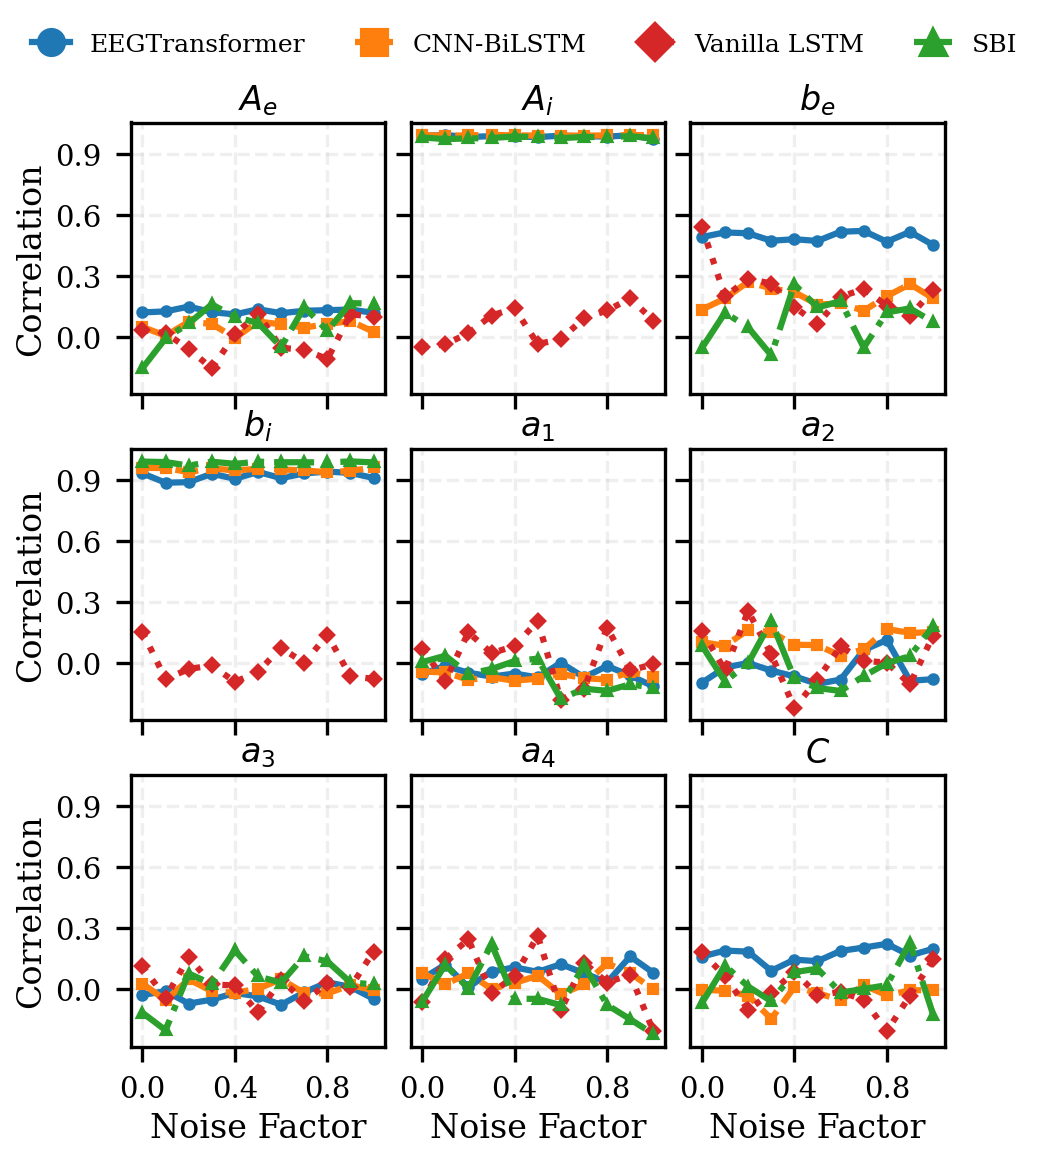

In [41]:
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl

def parse_txt_file_all(filename):
    """
    Parses a text file that may have two possible formats:
    
    Format 1 (single-line, e.g. EEG Transformer):
      Noise Factor: <noise>, MSE: <mse>, Correlations: { ... }
      
    Format 2 (multi-line, e.g. LSTM):
      [Optional header]
      Noise Factor: <noise>, MSE: <mse>
      Correlations:
        <key>: Corr=<corr_value>, R²=<r2_value>
        <key2>: Corr=<corr_value>, R²=<r2_value>
        ...
    
    Returns:
      - noise_factors: list of noise values (floats)
      - mse_values: list of MSE values (floats or None if missing)
      - correlations: dict where keys are parameter names and values are lists of the corresponding Pearson correlations.
    """
    noise_factors = []
    mse_values = []
    correlations = {}

    with open(filename, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue

        if "Noise Factor:" in line:
            # Extract noise factor and MSE from the line
            noise_match = re.search(r'Noise Factor:\s*([\d\.]+)', line)
            mse_match = re.search(r'MSE:\s*([\d\.eE\-\+]+)', line)
            if noise_match:
                noise = float(noise_match.group(1))
            else:
                i += 1
                continue
            mse = float(mse_match.group(1)) if mse_match else None

            noise_factors.append(noise)
            mse_values.append(mse)

            # Check if correlations dictionary is provided on the same line
            corr_match = re.search(r'Correlations:\s*(\{.*\})', line)
            if corr_match:
                corr_str = corr_match.group(1)
                try:
                    corr_dict = eval(corr_str)  # Ensure the file is trusted!
                except Exception as e:
                    print(f"Error parsing correlations in {filename}: {e}")
                    i += 1
                    continue
                for key, value in corr_dict.items():
                    if key not in correlations:
                        correlations[key] = []
                    correlations[key].append(value)
                i += 1
                continue

            # Otherwise, assume correlations follow on subsequent lines.
            # Skip blank lines until a line containing "Correlations:" is found.
            i += 1
            while i < len(lines) and lines[i].strip() == "":
                i += 1
            if i < len(lines) and "Correlations:" in lines[i]:
                i += 1  # Skip the "Correlations:" line
            else:
                continue

            # Process subsequent lines for correlation entries.
            while i < len(lines):
                corr_line = lines[i].strip()
                if not corr_line:
                    break
                # If a new block begins, stop processing the current block.
                if "Noise Factor:" in corr_line:
                    break
                # Expected format: <key>: Corr=<value>, R²=<value>
                corr_line_match = re.match(r'([\w]+):\s*Corr=([-\d\.]+)', corr_line)
                if corr_line_match:
                    key = corr_line_match.group(1)
                    try:
                        value = float(corr_line_match.group(2))
                    except ValueError:
                        value = None
                    if key not in correlations:
                        correlations[key] = []
                    correlations[key].append(value)
                i += 1
        else:
            i += 1

    return noise_factors, mse_values, correlations

# Parse the EEG Transformer, LSTM, and base LSTM text files
noise_eeg, mse_eeg, corr_eeg = parse_txt_file_all('evaluation_results_eegtransformer.txt')
noise_lstm, mse_lstm, corr_lstm = parse_txt_file_all('evaluation_results_lstm.txt')
noise_lstm_old, mse_lstm_old, corr_lstm_old = parse_txt_file_all('evaluation_results_lstm_old.txt')

# Load and parse the SBI JSON file (keys are noise factors)
with open('evalution_results_sbi.json', 'r') as f:
    sbi_data = json.load(f)

noise_sbi = []
mse_sbi = []
corr_sbi = {}
for noise_str, metrics in sbi_data.items():
    try:
        noise = float(noise_str)
    except ValueError:
        continue
    noise_sbi.append(noise)
    
    # Check if MSE is available in SBI data
    if 'MSE' in metrics:
        mse_sbi.append(metrics['MSE'])
    else:
        mse_sbi.append(None)
        
    for key, value in metrics.items():
        if key == 'MSE':
            continue
        if key not in corr_sbi:
            corr_sbi[key] = []
        corr_sbi[key].append(value)

def sort_data(noise, mse, correlations):
    """Sort noise, mse, and correlations by ascending noise factor."""
    noise = np.array(noise)
    sorted_idx = np.argsort(noise)
    noise_sorted = noise[sorted_idx]
    
    # Sort MSE values if they exist
    if mse and len(mse) > 0:
        mse_sorted = np.array(mse, dtype=float)[sorted_idx]
    else:
        mse_sorted = np.array([])
    
    correlations_sorted = {}
    for key, values in correlations.items():
        correlations_sorted[key] = np.array(values)[sorted_idx]
    
    return noise_sorted, mse_sorted, correlations_sorted

noise_eeg, mse_eeg, corr_eeg = sort_data(noise_eeg, mse_eeg, corr_eeg)
noise_lstm, mse_lstm, corr_lstm = sort_data(noise_lstm, mse_lstm, corr_lstm)
noise_lstm_old, mse_lstm_old, corr_lstm_old = sort_data(noise_lstm_old, mse_lstm_old, corr_lstm_old)
noise_sbi, mse_sbi, corr_sbi = sort_data(noise_sbi, mse_sbi, corr_sbi)

# Define the list of correlation keys to plot (common to all models)
common_keys = ['A_e', 'A_i', 'b_e', 'b_i', 'a_1', 'a_2', 'a_3', 'a_4', 'C']

# Gather min and max correlation values across all models and keys
all_corr_values = []
for key in common_keys:
    if key in corr_eeg:
        all_corr_values.extend(corr_eeg[key])
    if key in corr_lstm:
        all_corr_values.extend(corr_lstm[key])
    if key in corr_lstm_old:
        all_corr_values.extend(corr_lstm_old[key])
    if key in corr_sbi:
        all_corr_values.extend(corr_sbi[key])

if all_corr_values:
    global_min_corr = min(all_corr_values)
    global_max_corr = max(all_corr_values)
    # Add a small margin so points don't sit on the boundary
    margin = 0.05 * (global_max_corr - global_min_corr)
    if margin == 0:  # In case all values are the same
        margin = 0.1
    global_min_corr -= margin
    global_max_corr += margin
else:
    global_min_corr, global_max_corr = -0.3, 1.05

# Plot style for single column
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.labelpad': 2,
    'axes.titlepad': 3,
})

# Create a single figure with a 3x3 grid for correlation plots
fig, axs_params = plt.subplots(3, 3, figsize=(3.5, 4.0), sharex=True, sharey=True,
                               gridspec_kw={'wspace': 0.1, 'hspace': 0.2})
axs_params = axs_params.flatten()

# Update markers, colors, and linestyles to include LSTM_Old
markers = {'EEGTransformer': 'o', 'LSTM': 's', 'LSTM_Old': 'D', 'SBI': '^'}
colors = {'EEGTransformer': '#1f77b4', 'LSTM': '#ff7f0e', 'LSTM_Old': '#d62728', 'SBI': '#2ca02c'}
linestyles = {'EEGTransformer': '-', 'LSTM': '--', 'LSTM_Old': ':', 'SBI': '-.'}

for i, key in enumerate(common_keys):
    ax = axs_params[i]
    
    if key in corr_eeg:
        ax.plot(noise_eeg, corr_eeg[key],
                marker=markers['EEGTransformer'],
                color=colors['EEGTransformer'],
                linestyle=linestyles['EEGTransformer'],
                markersize=2)
    if key in corr_lstm:
        ax.plot(noise_lstm, corr_lstm[key],
                marker=markers['LSTM'],
                color=colors['LSTM'],
                linestyle=linestyles['LSTM'],
                markersize=2)
    if key in corr_lstm_old:
        ax.plot(noise_lstm_old, corr_lstm_old[key],
                marker=markers['LSTM_Old'],
                color=colors['LSTM_Old'],
                linestyle=linestyles['LSTM_Old'],
                markersize=2)
    if key in corr_sbi:
        ax.plot(noise_sbi, corr_sbi[key],
                marker=markers['SBI'],
                color=colors['SBI'],
                linestyle=linestyles['SBI'],
                markersize=2)
    
    # Format parameter name with subscript if needed
    if '_' in key:
        parts = key.split('_')
        main_param = parts[0]
        subscript = parts[1]
        param_formatted = main_param + '_{' + subscript + '}'
    else:
        param_formatted = key
    ax.set_title(f"${param_formatted}$", pad=3)
    
    ax.grid(True, linestyle='--', alpha=0.2)
    ax.set_ylim(global_min_corr, global_max_corr)
    
    if i % 3 == 0:
        ax.set_ylabel("Correlation", labelpad=2)
    if i >= 6:
        ax.set_xlabel("Noise Factor", labelpad=2)
    
    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.yaxis.set_major_locator(MaxNLocator(5))

# Create a dedicated legend axes.
legend_ax = fig.add_axes([0.25, 0.92, 0.5, 0.05])
legend_ax.axis('off')  # Hide frame and ticks

# Custom legend handles for all four models
handles = [
    mpl.lines.Line2D([], [], marker=markers['EEGTransformer'],
                     linestyle=linestyles['EEGTransformer'],
                     color=colors['EEGTransformer'],
                     label='EEGTransformer'),
    mpl.lines.Line2D([], [], marker=markers['LSTM'],
                     linestyle=linestyles['LSTM'],
                     color=colors['LSTM'],
                     label='CNN-BiLSTM'),
    mpl.lines.Line2D([], [], marker=markers['LSTM_Old'],
                     linestyle=linestyles['LSTM_Old'],
                     color=colors['LSTM_Old'],
                     label='Vanilla LSTM'),
    mpl.lines.Line2D([], [], marker=markers['SBI'],
                     linestyle=linestyles['SBI'],
                     color=colors['SBI'],
                     label='SBI')
]

legend_ax.legend(handles=handles,
                 loc='center',
                 ncol=4,
                 fontsize=6,
                 frameon=False,
                 handlelength=1.5)

plt.subplots_adjust(top=0.88)
plt.tight_layout()

filename_base = 'parameter_correlations'
plt.savefig(f'{filename_base}.pdf', bbox_inches='tight')
plt.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight')
plt.show()


KeyError: 'LSTM_Old'

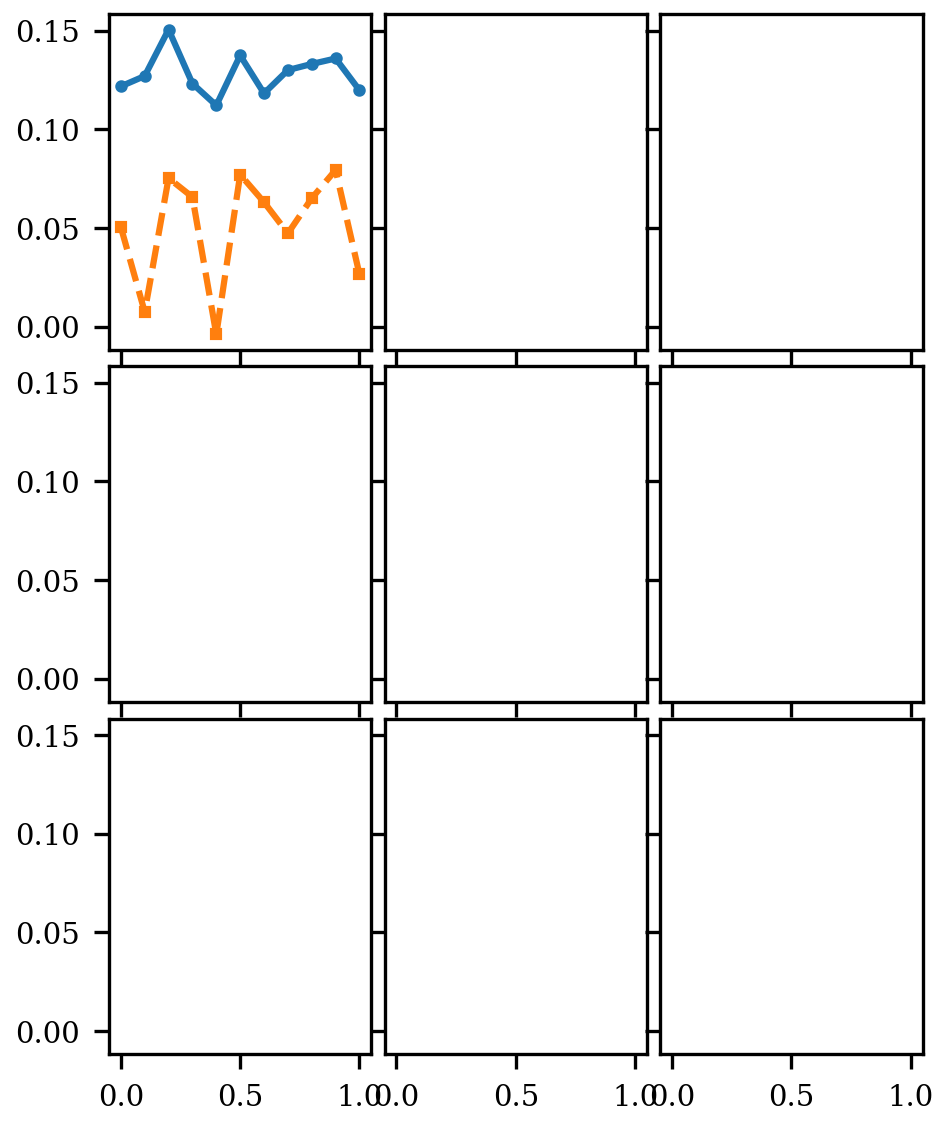

In [39]:
import math

# Dynamically calculate number of rows and columns based on number of keys
num_keys = len(common_keys)
n_cols = 3  # You can adjust this if you prefer more/less columns
n_rows = math.ceil(num_keys / n_cols)  # Minimum rows needed

# Create dynamic subplots
fig, axs_params = plt.subplots(n_rows, n_cols, figsize=(3.5, 1.5 * n_rows), 
                               sharex=True, sharey=True,
                               gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
axs_params = axs_params.flatten()

for i, key in enumerate(common_keys):
    ax = axs_params[i]

    # Plot only if data is present and valid
    if key in corr_eeg and len(corr_eeg[key]) > 0 and np.any(~np.isnan(corr_eeg[key])):
        ax.plot(noise_eeg, corr_eeg[key],
                marker=markers['EEGTransformer'],
                color=colors['EEGTransformer'],
                linestyle=linestyles['EEGTransformer'],
                markersize=2)

    if key in corr_lstm and len(corr_lstm[key]) > 0 and np.any(~np.isnan(corr_lstm[key])):
        ax.plot(noise_lstm, corr_lstm[key],
                marker=markers['LSTM'],
                color=colors['LSTM'],
                linestyle=linestyles['LSTM'],
                markersize=2)

    if key in corr_lstm_old and len(corr_lstm_old[key]) > 0 and np.any(~np.isnan(corr_lstm_old[key])):
        ax.plot(noise_lstm_old, corr_lstm_old[key],
                marker=markers['LSTM_Old'],
                color=colors['LSTM_Old'],
                linestyle=linestyles['LSTM_Old'],
                markersize=2)

    if key in corr_sbi and len(corr_sbi[key]) > 0 and np.any(~np.isnan(corr_sbi[key])):
        ax.plot(noise_sbi, corr_sbi[key],
                marker=markers['SBI'],
                color=colors['SBI'],
                linestyle=linestyles['SBI'],
                markersize=2)

    # Formatting parameter name
    if '_' in key:
        parts = key.split('_')
        param_formatted = parts[0] + '_{' + parts[1] + '}'
    else:
        param_formatted = key
    ax.set_title(f"${param_formatted}$", pad=3)

    ax.grid(True, linestyle='--', alpha=0.2)
    ax.set_ylim(global_min_corr, global_max_corr)

    # Axis labels only on edge plots
    if i % n_cols == 0:
        ax.set_ylabel("Correlation", labelpad=2)
    if i >= (n_rows - 1) * n_cols:
        ax.set_xlabel("Noise Factor", labelpad=2)

    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.yaxis.set_major_locator(MaxNLocator(5))

# Turn off any unused subplots if number of keys < grid size
for j in range(i + 1, len(axs_params)):
    axs_params[j].axis('off')

# Create a dedicated legend axes (unchanged)
legend_ax = fig.add_axes([0.1, 0.92, 0.8, 0.05])
legend_ax.axis('off')
handles = [
    mpl.lines.Line2D([], [], marker=markers['EEGTransformer'],
                     linestyle=linestyles['EEGTransformer'],
                     color=colors['EEGTransformer'],
                     label='EEGTransformer'),
    mpl.lines.Line2D([], [], marker=markers['LSTM'],
                     linestyle=linestyles['LSTM'],
                     color=colors['LSTM'],
                     label='CNN-BiLSTM'),
    mpl.lines.Line2D([], [], marker=markers['LSTM_Old'],
                     linestyle=linestyles['LSTM_Old'],
                     color=colors['LSTM_Old'],
                     label='Vanilla LSTM'),
    mpl.lines.Line2D([], [], marker=markers['SBI'],
                     linestyle=linestyles['SBI'],
                     color=colors['SBI'],
                     label='SBI')
]
legend_ax.legend(handles=handles,
                 loc='center',
                 ncol=4,
                 fontsize=6,
                 frameon=False,
                 handlelength=1.5)

plt.subplots_adjust(top=0.88)  # Adjust top for legend
plt.savefig(f'{filename_base}.pdf', bbox_inches='tight')
plt.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/q2/0fx0g8ps73191hn2jpcbj1mm0000gn/T/ipykernel_18887/2598692042.py:92: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_low_mse.set_ylim(-250, -150)
/var/folders/q2/0fx0g8ps73191hn2jpcbj1mm0000gn/T/ipykernel_18887/2598692042.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=0.05)


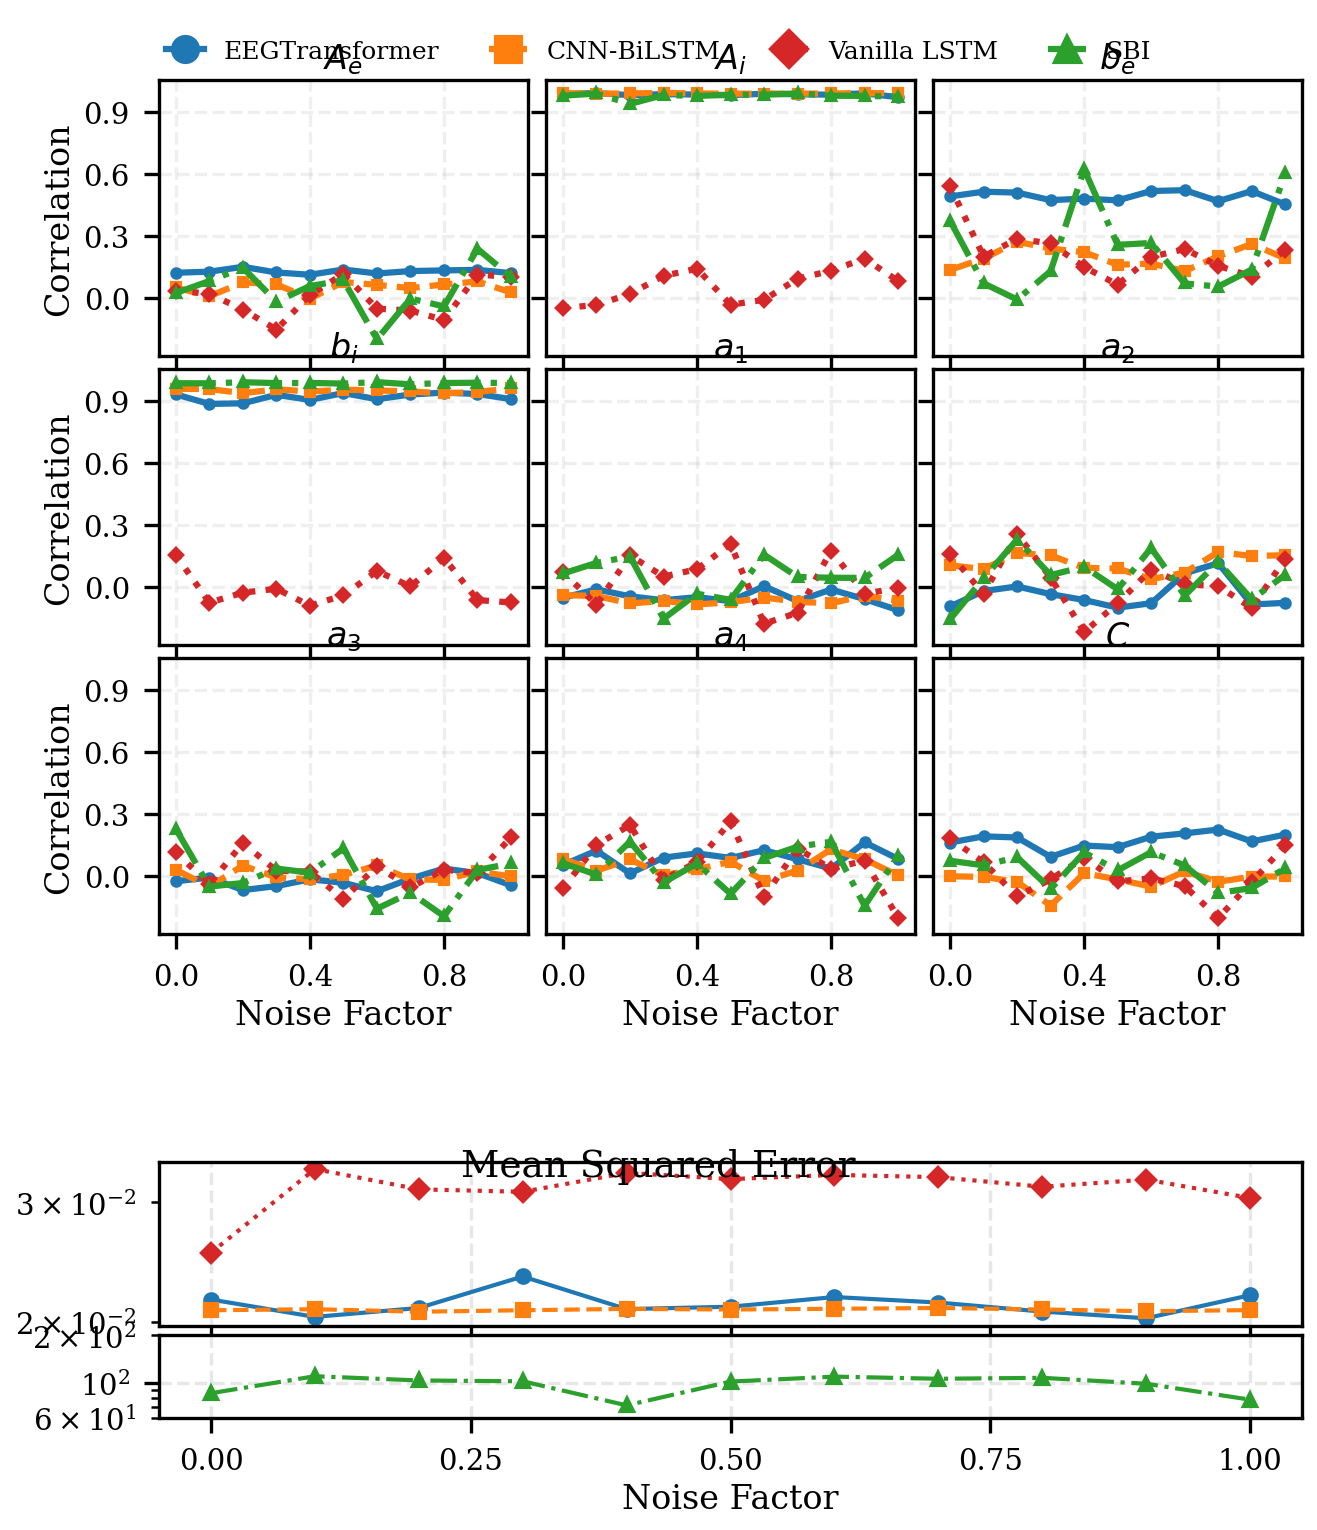

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator, ScalarFormatter
import matplotlib as mpl
import ast

# ---- Load everything from evaluation_results_with_estimates.json ---- #
with open('evaluation_results_with_estimates.json', 'r') as f:
    sbi_full_results = ast.literal_eval(f.read())  # Python dict-like

# ---- Prepare noise levels ---- #
noise_sbi = sorted(sbi_full_results.keys(), key=lambda x: float(x))  # Sorted numerically as strings

# ---- Extract correlations and MSE ---- #
corr_sbi = {key: [] for key in common_keys}
mse_sbi_per_param = {key: [] for key in common_keys}
mse_sbi = []  # Average MSE (excluding 'C')

# Fill in
for idx in noise_sbi:
    corr_data = sbi_full_results[float(idx)]['pearson_correlation']
    mse_data = sbi_full_results[float(idx)]['mse']
    
    for key in common_keys:
        corr_sbi[key].append(corr_data.get(key, np.nan))
        mse_sbi_per_param[key].append(mse_data.get(key, np.nan))
    
    mse_sbi.append(np.mean([mse_data[k] for k in common_keys if k != 'C']))  # Exclude 'C'

# Convert to np.array
noise_sbi = np.array([float(n) for n in noise_sbi])
mse_sbi = np.array(mse_sbi)

# ---- Plotting ---- #
fig = plt.figure(figsize=(4.5, 5.0))  # Slightly smaller height for compactness

# --- Subfigures for correlation and MSE --- #
subfigs = fig.subfigures(2, 1, height_ratios=[5, 1.5])  # Reduced MSE space
fig.subplots_adjust(hspace=0.04)  # Less vertical space between corr and MSE

# ---- Correlation Grids ---- #
axs_params = subfigs[0].subplots(3, 3, sharex=True, sharey=True,
                                 gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
axs_params = axs_params.flatten()

for i, key in enumerate(common_keys):
    ax = axs_params[i]
    
    # Plot correlations
    if key in corr_eeg:
        ax.plot(noise_eeg, corr_eeg[key], marker=markers['EEGTransformer'],
                color=colors['EEGTransformer'], linestyle=linestyles['EEGTransformer'], markersize=2)
    if key in corr_lstm:
        ax.plot(noise_lstm, corr_lstm[key], marker=markers['LSTM'],
                color=colors['LSTM'], linestyle=linestyles['LSTM'], markersize=2)
    if key in corr_lstm_old:
        ax.plot(noise_lstm_old, corr_lstm_old[key], marker=markers['LSTM_Old'],
                color=colors['LSTM_Old'], linestyle=linestyles['LSTM_Old'], markersize=2)
    if key in corr_sbi:
        ax.plot(noise_sbi, corr_sbi[key], marker=markers['SBI'],
                color=colors['SBI'], linestyle=linestyles['SBI'], markersize=2)

    # Formatting
    param_formatted = key.replace('_', '_{') + '}' if '_' in key else key
    ax.set_title(f"${param_formatted}$", pad=3, fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.2)
    ax.set_ylim(global_min_corr, global_max_corr)
    if i % 3 == 0:
        ax.set_ylabel("Correlation", fontsize=8)
    if i >= 6:
        ax.set_xlabel("Noise Factor", fontsize=8)
    ax.xaxis.set_major_locator(MaxNLocator(3))
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.tick_params(labelsize=7)

# ---- MSE Split Plots ---- #
# Create MSE split without internal legend, single title on top
ax_low_mse, ax_high_mse = subfigs[1].subplots(2, 1, sharex=True, height_ratios=[2, 1])

# ---- Low MSE Models ---- #
if isinstance(mse_eeg, np.ndarray) and mse_eeg.size > 0:
    ax_low_mse.plot(noise_eeg, mse_eeg, marker=markers['EEGTransformer'],
                    color=colors['EEGTransformer'], linestyle=linestyles['EEGTransformer'], markersize=3, linewidth=1)
if isinstance(mse_lstm, np.ndarray) and mse_lstm.size > 0:
    ax_low_mse.plot(noise_lstm, mse_lstm, marker=markers['LSTM'],
                    color=colors['LSTM'], linestyle=linestyles['LSTM'], markersize=3, linewidth=1)
if isinstance(mse_lstm_old, np.ndarray) and mse_lstm_old.size > 0:
    ax_low_mse.plot(noise_lstm_old, mse_lstm_old, marker=markers['LSTM_Old'],
                    color=colors['LSTM_Old'], linestyle=linestyles['LSTM_Old'], markersize=3, linewidth=1)

ax_low_mse.set_yscale('log')
ax_low_mse.set_ylim(-250, -150)
ax_low_mse.grid(True, linestyle='--', alpha=0.3)
ax_low_mse.yaxis.set_major_formatter(ScalarFormatter())
ax_low_mse.tick_params(labelsize=7)

# ---- High MSE (SBI) ---- #
ax_high_mse.plot(noise_sbi, mse_sbi, marker=markers['SBI'],
                 color=colors['SBI'], linestyle=linestyles['SBI'], markersize=3, linewidth=1)

ax_high_mse.set_yscale('log')
ax_high_mse.set_ylim(60, 200)
ax_high_mse.set_xlabel("Noise Factor", fontsize=8)
ax_high_mse.grid(True, linestyle='--', alpha=0.3)
ax_high_mse.xaxis.set_major_locator(MaxNLocator(5))
ax_high_mse.tick_params(labelsize=7)

# ---- Title for MSE ---- #
subfigs[1].suptitle("Mean Squared Error", fontsize=9, y=0.95)

# ---- Layout ---- #
plt.tight_layout(h_pad=0.05)

# ---- Global Legend (Top) ---- #
legend_ax = fig.add_axes([0.1, 0.925, 0.8, 0.05])
legend_ax.axis('off')
handles = [
    mpl.lines.Line2D([], [], marker=markers['EEGTransformer'], linestyle=linestyles['EEGTransformer'],
                     color=colors['EEGTransformer'], label='EEGTransformer'),
    mpl.lines.Line2D([], [], marker=markers['LSTM'], linestyle=linestyles['LSTM'],
                     color=colors['LSTM'], label='CNN-BiLSTM'),
    mpl.lines.Line2D([], [], marker=markers['LSTM_Old'], linestyle=linestyles['LSTM_Old'],
                     color=colors['LSTM_Old'], label='Vanilla LSTM'),
    mpl.lines.Line2D([], [], marker=markers['SBI'], linestyle=linestyles['SBI'],
                     color=colors['SBI'], label='SBI')
]
legend_ax.legend(handles=handles, loc='center', ncol=4, fontsize=6, frameon=False, handlelength=1.5)

plt.subplots_adjust(top=0.91)

# ---- Save final figure ---- #
plt.savefig(f'{filename_base}_final_combined.pdf', bbox_inches='tight')
plt.savefig(f'{filename_base}_final_combined.png', dpi=300, bbox_inches='tight')
plt.show()
